In [1]:
from typing import Sequence

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray

import jax
from jax import random
import jax.numpy as jnp
from optax import linear_onecycle_schedule

import numpyro
from numpyro import distributions as dist
from numpyro.contrib.hsgp.approximation import hsgp_squared_exponential
from numpyro.infer import Predictive
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.elbo import Trace_ELBO
from numpyro.infer.hmc import NUTS
from numpyro.infer.initialization import init_to_median, init_to_uniform
from numpyro.infer.mcmc import MCMC
from numpyro.infer.svi import SVI
from numpyro.optim import Adam

In [2]:
num_devices = 4
numpyro.set_host_device_count(num_devices)
jax.config.update("jax_enable_x64", True)  # additional precision for to avoid numerical issues with Cholesky decomposition of the covariance matrix

In [3]:
def se_kernel(X: jax.Array, Z: jax.Array, amplitude: float, length: float, noise: float | None, jitter=1.0e-6,) -> jax.Array:
    """Squared exponential kernel function."""
    r = jnp.linalg.norm(X[:, jnp.newaxis] - Z, axis=-1)
    delta = (r / length) ** 2
    k = (amplitude**2) * jnp.exp(-0.5 * delta)
    if noise is None:
        return k
    else:
        return k + (noise**2 + jitter) * jnp.eye(k.shape[0])

def sample_grid_and_data(N_grid: int, N: int, L: float, amplitude: float, lengthscale: float, noise: float, key: int, D: int,
                         ) -> tuple[jax.Array, jax.Array, jax.Array, jax.Array]:
    """Sample N_grid ** D points from noiseless function and N noisy data points from a GP."""

    # draw points on a grid for plotting surface of the noiseless function
    x_linspace = jnp.linspace(-L, L, N_grid)
    x_mesh = jnp.meshgrid(*[x_linspace for _ in range(D)])
    X_grid = jnp.concatenate([x_mesh[i].ravel()[..., None] for i in range(D)], axis=1)

    # draw data points from a uniform distribution on the support of the grid
    X = random.uniform(key, shape=(N, D), minval=-L, maxval=L)

    # concatenate grid and data points
    X_all = jnp.concatenate([X_grid, X], axis=0)

    # sample from the GP
    cov = se_kernel(X_all, X_all, amplitude, lengthscale, 0.0)  # noiseless
    _, key = random.split(key)
    _y = random.multivariate_normal(key, mean=jnp.zeros(cov.shape[0]), cov=cov)

    # separate the grid and data points
    y_grid = _y[0 : N_grid**D].reshape((N_grid,) * D)
    _, key = random.split(key)
    y = _y[N_grid**D :] + (
        random.normal(key, shape=(N,)) * noise
    )  # add noise to the data points

    y_mean = y.mean()

    return X_grid, y_grid - y_mean, X, y - y_mean

In [4]:
# parameters for the synthetic data
D = 2
N_grid = 25 if D == 2 else 100
N = 1_000
L = 3.0

# kernel parameters
amplitude = 1.0
lengthscale = 2.0

# noise level
noise = 0.5 if D == 2 else 0.15

# sample the grid and data
seed = 0
key = jax.random.key(seed)

X_grid, y_grid, X, y = sample_grid_and_data(N_grid, N, L, amplitude, lengthscale, noise, key, D)

W0309 20:04:44.646344 1241835 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [5]:
def plot_surface_scatter(
    N_grid: int,
    X_grid: NDArray | None = None,
    y_grid: NDArray | None = None,
    X: NDArray | None = None,
    y: NDArray | None = None,
    test_ind: jax.Array | None = None,
    post_y: jax.Array | None = None,
    xz_lines: list[tuple[jax.Array, jax.Array, float]] | None = None,
    yz_lines: list[tuple[jax.Array, jax.Array, float]] | None = None,
    xy_annotate_lines: Sequence[
        tuple[tuple[float, float], tuple[float, float]] | None
    ] = None,
    fig_size: float = 8.0,
    label_size: float = 8.0,
    grid_alpha: float = 0.1,
    y_wireframe_alpha: float = 1.0,
    post_alpha: float = 0.1,
    point_size: float = 1.0,
    point_alpha: float = 0.5,
    ci_alpha: float = 0.1,
) -> None:
    # setup figure
    fig = plt.figure(figsize=(fig_size, fig_size))

    # plot the surface of the noiseless function and the data points
    x0_grid, x1_grid = (
        X_grid[:, 0].reshape((N_grid, N_grid)),
        X_grid[:, 1].reshape((N_grid, N_grid)),
    )
    ax = fig.add_subplot(projection="3d")

    # plot wireframes from draws from the posterior
    if post_y is not None:
        for i in range(post_y.shape[0]):
            post_y_grid = post_y[i, :].reshape((N_grid, N_grid))
            ax.plot_wireframe(
                x0_grid,
                x1_grid,
                post_y_grid,
                rstride=1,
                cstride=1,
                linewidth=1.0,
                alpha=post_alpha,
                color="tab:blue",
            )

    # plot the data points
    if X is not None and y is not None:
        color = (
            "tab:blue"
            if test_ind is None
            else np.where(test_ind, "tab:green", "tab:blue")
        )
        ax.scatter(
            xs=X[:, 0],
            ys=X[:, 1],
            zs=y,
            c=color,
            s=point_size,
            alpha=point_alpha,
        )

    # add confidence intervals at the boundaries
    if xz_lines:
        for line in xz_lines:
            x, z, y = line
            ax.plot(
                x, z, zs=y, zdir="y", color="tab:green", linestyle="--", alpha=ci_alpha
            )
    if yz_lines:
        for line in yz_lines:
            y, z, x = line
            ax.plot(
                y, z, zs=x, zdir="x", color="tab:green", linestyle="--", alpha=ci_alpha
            )

    # plot the surface of the noiseless function
    if y_grid is not None:
        ax.plot_wireframe(
            x0_grid,
            x1_grid,
            y_grid,
            rstride=1,
            cstride=1,
            linewidths=1.0,
            alpha=y_wireframe_alpha,
            color="tab:orange",
        )

    # add box in xy plane
    z_min = ax.get_zlim()[0]
    ax.set_zlim(ax.get_zlim())
    if xy_annotate_lines:
        for line in xy_annotate_lines:
            x_bounds, y_bounds = line
            z_bounds = (z_min, z_min)
            ax.plot(
                x_bounds,
                y_bounds,
                z_bounds,
                color="tab:gray",
                alpha=0.5,
                linestyle="--",
            )

    # remove background panes
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("w")
    ax.yaxis.pane.set_edgecolor("w")
    ax.zaxis.pane.set_edgecolor("w")

    # configure grid
    ax.xaxis._axinfo["grid"]["color"] = ("tab:gray", grid_alpha)
    ax.yaxis._axinfo["grid"]["color"] = ("tab:gray", grid_alpha)
    ax.zaxis._axinfo["grid"]["color"] = ("tab:gray", grid_alpha)

    # set labels and ticks
    ax.xaxis.set_tick_params(labelsize=label_size)
    ax.set_xlabel("x0", fontsize=label_size)
    ax.yaxis.set_tick_params(labelsize=label_size)
    ax.set_ylabel("x1", fontsize=label_size)
    ax.zaxis.set_tick_params(labelsize=label_size)
    ax.set_zlabel("y", fontsize=label_size)

    ax.set_box_aspect(aspect=None, zoom=0.9)
    return ax


def plot_line_scatter(
    X_grid: jax.Array,
    y_grid: jax.Array,
    X: jax.Array | None = None,
    y: jax.Array | None = None,
    test_ind: jax.Array | None = None,
    post_y: jax.Array | None = None,
    v_lines: Sequence[float] | None = None,
    ci: tuple[jax.Array, jax.Array] | None = None,
    fig_size: float = 5.0,
    label_size: float = 8.0,
    post_alpha: float = 0.25,
    point_size: float = 1.0,
    point_alpha: float = 0.25,
    ci_alpha: float = 0.1,
):
    fig = plt.figure(figsize=(fig_size, fig_size))
    ax = fig.add_subplot()

    # plot draws of the function from the posterior
    if post_y is not None:
        for i in range(post_y.shape[0]):
            ax.plot(
                X_grid, post_y[i, :], linewidth=1.0, alpha=post_alpha, color="tab:blue"
            )

    # plot the data points
    if X is not None and y is not None:
        if test_ind is None:
            color = "tab:blue"
        else:
            test_ind = np.array(test_ind).squeeze()
            color = np.where(test_ind, "tab:green", "tab:blue")
        ax.scatter(X, y, c=color, s=point_size, alpha=point_alpha)

    # add confidence intervals
    if ci:
        ax.fill_between(
            X_grid.squeeze(), ci[0], ci[1], color="tab:blue", alpha=ci_alpha
        )

    # add the noiseless function
    ax.plot(X_grid, y_grid, linewidth=1.0, alpha=1.0, color="tab:orange")

    # add vertical lines denoting boundaries of the training data
    if v_lines:
        for v_line in v_lines:
            plt.axvline(v_line, color="tab:gray", linestyle="--", alpha=0.5)
            plt.axvline(v_line, color="tab:gray", linestyle="--", alpha=0.5)

    # set labels and ticks
    ax.set_xlabel("x", fontsize=label_size)
    ax.set_ylabel("y", fontsize=label_size)
    ax.xaxis.set_tick_params(labelsize=label_size)
    ax.yaxis.set_tick_params(labelsize=label_size)

    return ax

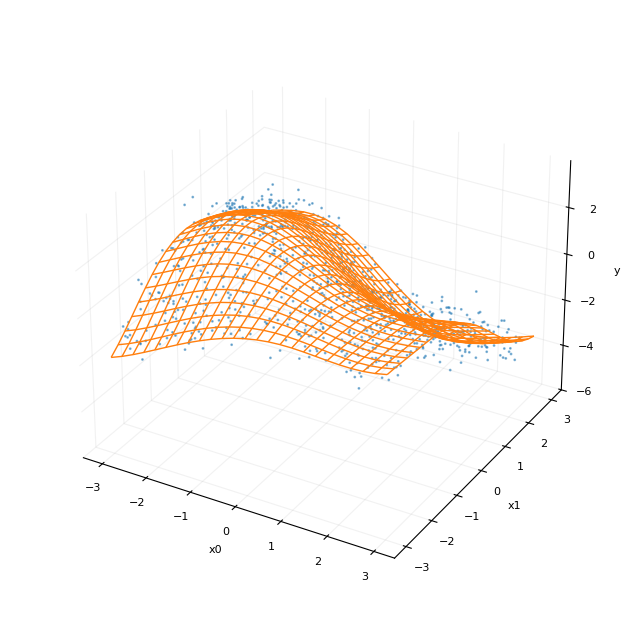

In [6]:
if D == 2:
    plot_surface_scatter(N_grid, X_grid, y_grid, X, y)
elif D == 1:
    plot_line_scatter(
        X_grid,
        y_grid,
        X,
        y,
    )
plt.show()

In [7]:
@jax.tree_util.register_pytree_node_class  # https://github.com/jax-ml/jax/discussions/16020
class GPModel:
    """Exact GP model with a squared exponential kernel."""

    def __init__(self, X: jax.Array, y: jax.Array):
        self.X = X
        self.y = y

    def model(self, X_test: jax.Array | None = None):
        amplitude = numpyro.sample("amplitude", dist.LogNormal(0, 1))
        length = numpyro.sample("lengthscale", dist.Exponential(1))
        noise = numpyro.sample("noise", dist.LogNormal(0, 1))

        k = se_kernel(self.X, self.X, amplitude, length, noise)

        if X_test is not None:  # predictive distribution
            k_inv = jnp.linalg.inv(k)
            k_star = se_kernel(X_test, self.X, amplitude, length, noise=None)
            k_star_star = se_kernel(X_test, X_test, amplitude, length, noise)

            f_star = numpyro.deterministic("f_star", k_star @ (k_inv @ self.y))
            cov_star = k_star_star - (k_star @ k_inv @ k_star.T)
            numpyro.sample(
                "y_test",
                dist.MultivariateNormal(loc=f_star, covariance_matrix=cov_star),
            )
        else:
            numpyro.sample(
                "y", dist.MultivariateNormal(loc=0, covariance_matrix=k), obs=self.y
            )

    def tree_flatten(self):
        children = (self.X, self.y)  # arrays / dynamic values
        aux_data = {}  # static values
        return (children, aux_data)

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children, **aux_data)

In [8]:
tr_frac = 0.8  # train on data contained within the inner tr_frac fraction of the domain
tr_idx = ((X > -L * tr_frac) & (X < L * tr_frac)).sum(axis=1) == D
tr_idx_grid = ((X_grid > -L * tr_frac) & (X_grid < L * tr_frac)).sum(axis=1) == D

X_tr = X[tr_idx]  # train on values set away from the edges
X_test = X[~tr_idx]
y_tr = y[tr_idx]
y_test = y[~tr_idx]

m = GPModel(X_tr, y_tr)

In [9]:
INFERENCE = "mcmc"


def fit_mcmc(
    seed: int,
    model: callable,
    num_warmup: int = 500,
    num_samples: int = 500,
    target_accept_prob: float = 0.8,
    init_strategy: callable = init_to_uniform,
    **model_kwargs,
):
    rng_key = random.PRNGKey(seed)
    kernel = NUTS(
        model, target_accept_prob=target_accept_prob, init_strategy=init_strategy
    )
    mcmc = MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=4,
        progress_bar=False,
    )
    mcmc.run(rng_key, **model_kwargs)
    return mcmc


def fit_svi(
    seed: int,
    model: callable,
    guide: callable,
    num_steps: int = 5000,
    peak_lr: float = 0.01,
    **model_kwargs,
):
    lr_scheduler = linear_onecycle_schedule(num_steps, peak_lr)
    svi = SVI(model, guide, Adam(lr_scheduler), Trace_ELBO())
    return svi.run(random.PRNGKey(seed), num_steps, progress_bar=False, **model_kwargs)

In [10]:
if INFERENCE == "mcmc":
    mcmc = fit_mcmc(seed, m.model)
else:
    guide = AutoNormal(m.model, init_loc_fn=init_to_median(num_samples=25))
    svi_res = fit_svi(seed=seed, model=m.model, guide=guide)

In [ ]:
## ~13 min
if INFERENCE == "mcmc":
    idata = az.from_numpyro(posterior=mcmc)
    mcmc.print_summary()


                   mean       std    median      5.0%     95.0%     n_eff     r_hat
    amplitude      1.66      0.53      1.55      0.91      2.36    785.65      1.01
  lengthscale      2.12      0.28      2.10      1.67      2.58    703.61      1.01
        noise      0.49      0.01      0.49      0.47      0.52   1401.27      1.00

Number of divergences: 0


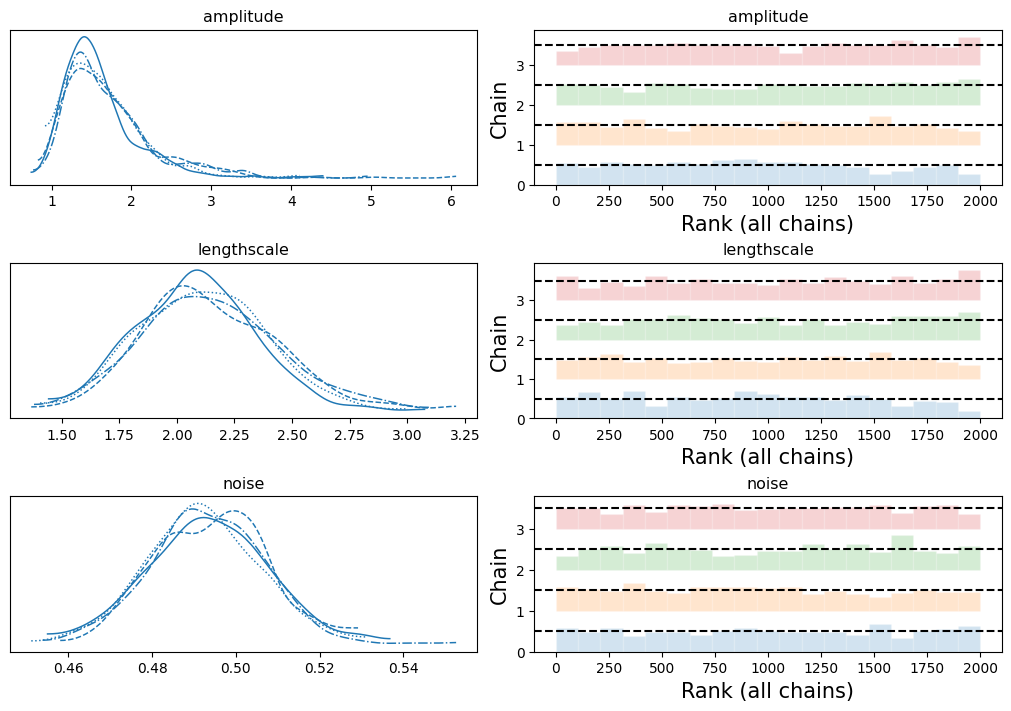

In [12]:
if INFERENCE == "mcmc":
    VAR_NAMES = ["amplitude", "lengthscale", "noise"]
    axes = az.plot_trace(
        data=idata,
        var_names=VAR_NAMES,
        kind="rank_bars",
        backend_kwargs={"figsize": (10, 7), "layout": "constrained"},
    )

In [13]:
def posterior_predictive_mcmc(
    seed: int,
    model: callable,
    mcmc: MCMC,
    **model_kwargs,
) -> dict[str, jax.Array]:
    samples = mcmc.get_samples()
    predictive = Predictive(model, samples, parallel=True)
    return predictive(random.PRNGKey(seed), **model_kwargs)


def posterior_predictive_svi(
    seed: int,
    model: callable,
    guide: callable,
    params: dict,
    num_samples: int = 2000,
    **model_kwargs,
) -> dict[str, jax.Array]:
    predictive = Predictive(model, guide=guide, params=params, num_samples=num_samples)
    return predictive(random.PRNGKey(seed), **model_kwargs)

In [ ]:
## ~ 14 min
if INFERENCE == "mcmc":
    post_y = posterior_predictive_mcmc(seed, m.model, mcmc, X_test=X_grid)
else:
    post_y = posterior_predictive_svi(
        seed, m.model, guide, svi_res.params, X_test=X_grid
    )

In [15]:
def plot_fit_result(
    N_post: int, post: dict[str, jax.Array], q_lower: float = 0.1, q_upper: float = 0.9
):
    ci = np.quantile(post["y_test"], jnp.array([q_lower, q_upper]), axis=0)
    if D == 1:
        ci_lower, ci_upper = ci[0, :], ci[1, :]
        test_ind = (X < -L * tr_frac) | (X > L * tr_frac)
        ax = plot_line_scatter(
            X_grid,
            y_grid,
            X,
            y,
            test_ind=test_ind,
            post_y=post["f_star"][0:N_post, :],
            post_alpha=0.1,
            point_alpha=0.15,
            v_lines=[-L * tr_frac, L * tr_frac],
            ci=(ci_lower, ci_upper),
            fig_size=5.0,
        )
    elif D == 2:
        # compute confidence intervals at the edges of the grid
        yz_ind1 = X_grid[:, 0] == L
        yz_lower1 = ci[0, :][yz_ind1]
        yz_upper1 = ci[1, :][yz_ind1]
        yz_ind2 = X_grid[:, 0] == -L
        yz_lower2 = ci[0, :][yz_ind2]
        yz_upper2 = ci[1, :][yz_ind2]

        xz_ind1 = X_grid[:, 1] == L
        xz_lower1 = ci[0, :][xz_ind1]
        xz_upper1 = ci[1, :][xz_ind1]
        xz_ind2 = X_grid[:, 1] == -L
        xz_lower2 = ci[0, :][xz_ind2]
        xz_upper2 = ci[1, :][xz_ind2]

        ax = plot_surface_scatter(
            N_grid=N_grid,
            X_grid=X_grid,
            y_grid=y_grid,
            X=X,
            y=y,
            test_ind=~tr_idx,
            post_y=post["f_star"][0:N_post, :],
            post_alpha=0.1,
            xy_annotate_lines=[
                ((-L * tr_frac, -L * tr_frac), (-L * tr_frac, L * tr_frac)),
                ((-L * tr_frac, L * tr_frac), (L * tr_frac, L * tr_frac)),
                ((L * tr_frac, L * tr_frac), (-L * tr_frac, L * tr_frac)),
                ((L * tr_frac, -L * tr_frac), (-L * tr_frac, -L * tr_frac)),
            ],
            yz_lines=[
                (X_grid[yz_ind1, 1], yz_lower1, L),
                (X_grid[yz_ind1, 1], yz_upper1, L),
                (X_grid[yz_ind2, 1], yz_lower2, -L),
                (X_grid[yz_ind2, 1], yz_upper2, -L),
            ],
            xz_lines=[
                (X_grid[xz_ind1, 0], xz_lower1, L),
                (X_grid[xz_ind1, 0], xz_upper1, L),
                (X_grid[xz_ind2, 0], xz_lower2, -L),
                (X_grid[xz_ind2, 0], xz_upper2, -L),
            ],
            y_wireframe_alpha=0.4,
            ci_alpha=0.75,
        )
    return ax


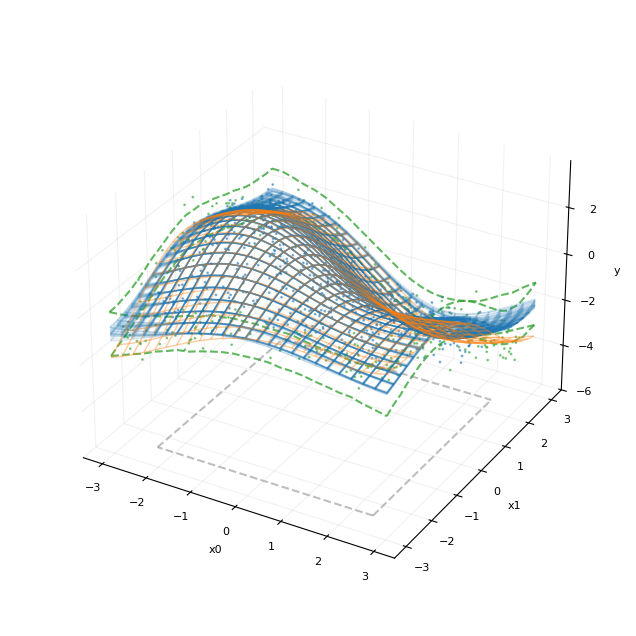

In [16]:
plot_fit_result(20, post_y)
plt.show()

In [17]:
def plot_calibration(
    y_true: jax.Array,
    y_pred: jax.Array,
    test_ind: jax.Array | None = None,
    fig_size: float = 5.0,
    label_size: float = 8.0,
    point_size: float = 1.0,
    x_label: str = "True",
    y_label: str = "Predicted",
):
    fig = plt.figure(figsize=(fig_size, fig_size))
    ax = fig.add_subplot()
    color = (
        "tab:blue" if test_ind is None else np.where(test_ind, "tab:green", "tab:blue")
    )
    ax.scatter(y_true, y_pred, c=color, alpha=0.5, s=point_size)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="tab:orange",
        linestyle="--",
    )
    ax.set_xlim([y_true.min(), y_true.max()])
    ax.set_ylim([y_true.min(), y_true.max()])
    ax.xaxis.set_tick_params(labelsize=label_size)
    ax.set_xlabel(x_label, fontsize=label_size)
    ax.yaxis.set_tick_params(labelsize=label_size)
    ax.set_ylabel(y_label, fontsize=label_size)
    return ax


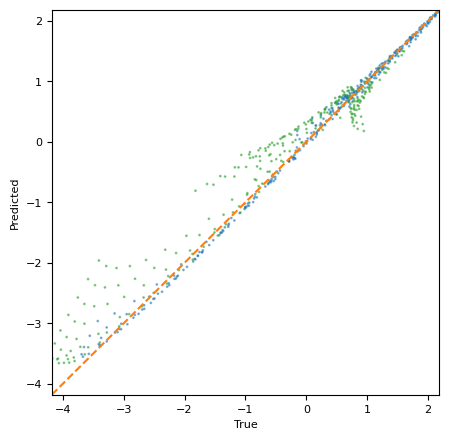

In [18]:
ax = plot_calibration(
    y_grid,
    post_y["f_star"].mean(axis=0),
    test_ind=~tr_idx_grid,
    point_size=1.0 if D == 2 else 5.0,
)
plt.show()

In [19]:
if INFERENCE == "mcmc":
    post_y_test = posterior_predictive_mcmc(seed, m.model, mcmc, X_test=X_test)
else:
    post_y_test = posterior_predictive_svi(
        seed, m.model, guide, svi_res.params, X_test=X_test
    )
print(
    "Test RMSE:",
    jnp.sqrt(jnp.mean((post_y_test["y_test"].mean(axis=0) - y_test) ** 2)),
)

Test RMSE: 0.60365939750065
